In [9]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
from roboflow import Roboflow
rf = Roboflow(api_key="EnyYEAry3FTybph77K2I")
project = rf.workspace("yolov8car").project("car-and-pedestrian-qbzyx")
version = project.version(1)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...


In [4]:
model = YOLO("best.pt")

In [5]:
from pathlib import Path

test_path = Path("../avsens_assignment/car-and-pedestrian--1/test/images")

print(test_path.exists())

True


In [7]:
results = model.predict(
    source= "../avsens_assignment/car-and-pedestrian--1/test/images",
    conf=0.25,
    save=True
)


image 1/20 c:\Users\B HEMANTH\OneDrive\Desktop\avsens_assignment\..\avsens_assignment\car-and-pedestrian--1\test\images\-1058CFB8-55AA-4270-937C-FAB55C49F17A-png_jpg.rf.a1061151a5cd92acdb232bf3289d0f08.jpg: 640x640 2 cars, 326.3ms
image 2/20 c:\Users\B HEMANTH\OneDrive\Desktop\avsens_assignment\..\avsens_assignment\car-and-pedestrian--1\test\images\-1EE5CA55-C89F-4985-8D4E-A56DBD1A1E96-png_jpg.rf.f83419a3fab3065cfac77d0011913c31.jpg: 640x640 2 cars, 104.7ms
image 3/20 c:\Users\B HEMANTH\OneDrive\Desktop\avsens_assignment\..\avsens_assignment\car-and-pedestrian--1\test\images\-26D423C9-C9F8-4CA3-B49E-3664225FB20C-png_jpg.rf.e30382c31215dcc537635640285a49ab.jpg: 640x640 2 cars, 3 pedestrians, 157.7ms
image 4/20 c:\Users\B HEMANTH\OneDrive\Desktop\avsens_assignment\..\avsens_assignment\car-and-pedestrian--1\test\images\-375329E9-678F-4B48-AED2-472A7ED60D19-png_jpg.rf.23d4cc9801f6f8d3a252d8fc0877c039.jpg: 640x640 1 car, 118.0ms
image 5/20 c:\Users\B HEMANTH\OneDrive\Desktop\avsens_assignm

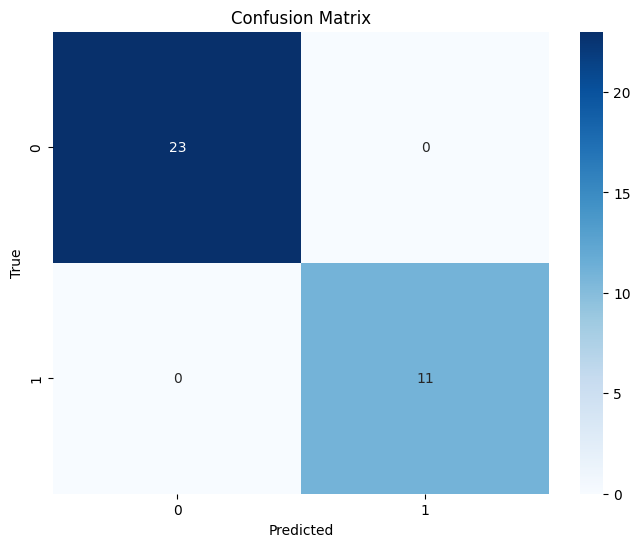

In [10]:
y_true = []
y_pred = []
for result in results:
  pred = result.boxes.cls.cpu().numpy()
  true = result.boxes.cls.cpu().numpy()

  y_pred.extend(pred)
  y_true.extend(true)

cm = confusion_matrix(y_true, y_pred)


plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()